<a href="https://colab.research.google.com/github/sandro-silva/Data/blob/master/classificacao2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **APRENDIZAGEM SUPERVISIONADA: CLASSIFICAÇÃO**

Este projeto tem por objetivo desenvolver um algoritmo de Machine Learning para prever a tendência de uma pessoa desenvolver algum tipo de doença cardíaca com base em alguns fatores clínicos e laboratoriais.

Os dados foram extraídos do site do Kaggle:

https://www.kaggle.com/fedesoriano/heart-failure-prediction/version/1

# **PRÉ-PROCESSAMENTO**

In [31]:
import numpy as np
import pandas as pd

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
df = pd.read_csv('/content/drive/MyDrive/Cursos_Udemy/Machine_Learning_com_Python/heart_tratado.csv',
                    sep=';', encoding='utf-8')

In [34]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [35]:
df.shape

(917, 12)

In [36]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,float64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


## **Transformando as variáveis categóricas nominais em variáveis categóricas ordinais**

In [37]:
df2 = pd.DataFrame.copy(df)

In [ ]:
df2['Sex'].replace({'M':0, 'F': 1}, inplace=True)
df2['ChestPainType'].replace({'TA':0, 'ATA': 1, 'NAP':2, 'ASY': 3}, inplace=True)
df2['RestingECG'].replace({'Normal':0, 'ST': 1, 'LVH':2}, inplace=True)
df2['ExerciseAngina'].replace({'N':0, 'Y': 1}, inplace=True)
df2['ST_Slope'].replace({'Up':0, 'Flat': 1, 'Down':2}, inplace=True)

In [38]:
df2.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [39]:
df2.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,float64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [40]:
df2.shape

(917, 12)

## **LEGENDA**

Age = idade (anos)

Sex = sexo (0=M; 1=F)

Chest Pain Type = tipo de dor no peito (0=TA:angina típica; 1=ATA:angina atípica; 2=NAP:dor não anginosa; 3=ASY:assintomático)

Resting BP = pressão sanguínea em repouso (mmHg)

Cholesterol = colesterol sérico (mg/dl)

Fasting BS = açúcar no sangue em jejum (mg/dl)
          0: Fasting BS < 120 mg/dl (não diabético)
          1: Fasting BS >= 120 mg/dl, (diabético)

Resting ECG = eletrocardiograma em repouso (0=Normal; 1=ST:Anormalidade da onda ST-T; 2=LVH: Hipertrofia ventricular esquerda)

Max HR = frequência cardíaca máxima

Exercise Angina = Angina induzida por exercício (0=Não; 1=Sim)

Old Peak = Depressão de ST induzida por exercício em relação ao repouso

ST_Slope = Inclinação do segmento ST (0=UP; 1=Flat; 2=Down)

Heart Disease = Doença cardíaca (0=Não possui doença cardíaca; 1=Possui doença cardíaca)



## **ATRIBUTOS PREVISORES E ALVO**

In [41]:
df2.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [42]:
previsores = df2.iloc[:, 0:11].values


In [43]:
previsores

array([[40, 'M', 'ATA', ..., 'N', 0.0, 'Up'],
       [49, 'F', 'NAP', ..., 'N', 1.0, 'Flat'],
       [37, 'M', 'ATA', ..., 'N', 0.0, 'Up'],
       ...,
       [57, 'M', 'ASY', ..., 'Y', 1.2, 'Flat'],
       [57, 'F', 'ATA', ..., 'N', 0.0, 'Flat'],
       [38, 'M', 'NAP', ..., 'N', 0.0, 'Up']], dtype=object)

In [44]:
previsores.shape

(917, 11)

In [45]:
alvo = df2.iloc[:, 11].values

In [46]:
alvo

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,

In [47]:
alvo.shape

(917,)

## **Análise das escalas dos atributos (Escalonamento)**

In [48]:
df2.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,244.635389,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,53.347125,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,244.635389,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Padronização (utiliza a média e o desvio padrão como referência).

Normalização (utiliza os valores máximo e mínimo como referência).

In [51]:
from sklearn.preprocessing import StandardScaler

In [ ]:
previsores_esc

In [ ]:
previsoresdf = pd.DataFrame(previsores_esc)
previsoresdf

In [ ]:
previsoresdf.describe()

## **Codificação de variáveis categóricas**

### **LabelEncoder: transformação de variáveis categóricas em numéricas**


In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [11]:
previsores2 = df.iloc[:, 0:11].values
previsores2

array([[40, 'M', 'ATA', ..., 'N', 0.0, 'Up'],
       [49, 'F', 'NAP', ..., 'N', 1.0, 'Flat'],
       [37, 'M', 'ATA', ..., 'N', 0.0, 'Up'],
       ...,
       [57, 'M', 'ASY', ..., 'Y', 1.2, 'Flat'],
       [57, 'F', 'ATA', ..., 'N', 0.0, 'Flat'],
       [38, 'M', 'NAP', ..., 'N', 0.0, 'Up']], dtype=object)

In [12]:
previsores2[:,1] = LabelEncoder().fit_transform(previsores2[:,1])

In [13]:
previsores2

array([[40, 1, 'ATA', ..., 'N', 0.0, 'Up'],
       [49, 0, 'NAP', ..., 'N', 1.0, 'Flat'],
       [37, 1, 'ATA', ..., 'N', 0.0, 'Up'],
       ...,
       [57, 1, 'ASY', ..., 'Y', 1.2, 'Flat'],
       [57, 0, 'ATA', ..., 'N', 0.0, 'Flat'],
       [38, 1, 'NAP', ..., 'N', 0.0, 'Up']], dtype=object)

In [14]:
previsores2[:,2] = LabelEncoder().fit_transform(previsores2[:,2])
previsores2[:,6] = LabelEncoder().fit_transform(previsores2[:,6])
previsores2[:,8] = LabelEncoder().fit_transform(previsores2[:,8])
previsores2[:,10] = LabelEncoder().fit_transform(previsores2[:,10])

In [15]:
previsores2

array([[40, 1, 1, ..., 0, 0.0, 2],
       [49, 0, 2, ..., 0, 1.0, 1],
       [37, 1, 1, ..., 0, 0.0, 2],
       ...,
       [57, 1, 0, ..., 1, 1.2, 1],
       [57, 0, 1, ..., 0, 0.0, 1],
       [38, 1, 2, ..., 0, 0.0, 2]], dtype=object)

In [16]:
previsores2.shape

(917, 11)

### **OneHotEncoder: Criação de variáveis Dummy (fictícia).**

Cuidado com a multicolinearidade (variáveis altamente correlacionadas entre si).

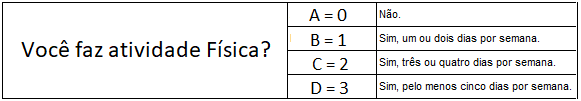

A   B   C   D   
1   0   0   0   
0   1   0   0   
0   0   1   0   
0   0   0   1


In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [19]:
ColumnTransformer?

Parâmetros ColumnTransformer
- name: nome dado a transformação.
- transformer: tipo de estimador (OneHotEncoder).
- columns: colunas que serão transformadas.
- remainder: o que acontecerá com o restante das colunas não relacionadas:
1) drop = exclui as outras colunas.
2) passthrough = mantém as outras colunas. drop é default.  
- sparse_threshold: parâmetro de classificação de matrizes esparsas. default é 0.3
- n_jobs: número de trabalhos a serem executados em paralelo. default é nenhum
- transformer_weights: definição de pesos aos transformadores.
-verbose: default é False. se for True a execução é apresentada na tela.

In [20]:
previsores3 = ColumnTransformer(transformers=[('OneHot', OneHotEncoder(), [1,2,6,8,10])],
                                remainder='passthrough').fit_transform(previsores2)

In [21]:
previsores3

array([[0.0, 1.0, 0.0, ..., 0, 172, 0.0],
       [1.0, 0.0, 0.0, ..., 0, 156, 1.0],
       [0.0, 1.0, 0.0, ..., 0, 98, 0.0],
       ...,
       [0.0, 1.0, 1.0, ..., 0, 115, 1.2],
       [1.0, 0.0, 0.0, ..., 0, 174, 0.0],
       [0.0, 1.0, 0.0, ..., 0, 173, 0.0]], dtype=object)

In [22]:
previsores3.shape

(917, 20)

In [23]:
previsores3df = pd.DataFrame(previsores3)
previsores3df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,40,140,289.0,0,172,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,49,160,180.0,0,156,1.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,37,130,283.0,0,98,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,48,138,214.0,0,108,1.5
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,54,150,195.0,0,122,0.0


In [24]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


## **Escalonamento**

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
previsores3_esc = StandardScaler().fit_transform(previsores3)

In [27]:
previsores3_esc

array([[-0.51630861,  0.51630861, -1.08542493, ..., -0.55173333,
         1.38333943, -0.83150225],
       [ 1.9368261 , -1.9368261 , -1.08542493, ..., -0.55173333,
         0.75473573,  0.10625149],
       [-0.51630861,  0.51630861, -1.08542493, ..., -0.55173333,
        -1.52395266, -0.83150225],
       ...,
       [-0.51630861,  0.51630861,  0.92129817, ..., -0.55173333,
        -0.85606123,  0.29380223],
       [ 1.9368261 , -1.9368261 , -1.08542493, ..., -0.55173333,
         1.46191489, -0.83150225],
       [-0.51630861,  0.51630861, -1.08542493, ..., -0.55173333,
         1.42262716, -0.83150225]])

In [28]:
previsores3df = pd.DataFrame(previsores3_esc)
previsores3df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.516309,0.516309,-1.085425,2.073784,-0.531524,-0.229810,-0.507826,0.815013,-0.490781,0.824310,-0.824310,-0.271607,-1.001091,1.149573,-1.432206,0.414627,0.832075,-0.551733,1.383339,-0.831502
1,1.936826,-1.936826,-1.085425,-0.482210,1.881384,-0.229810,-0.507826,0.815013,-0.490781,0.824310,-0.824310,-0.271607,0.998910,-0.869888,-0.478057,1.526360,-1.212261,-0.551733,0.754736,0.106251
2,-0.516309,0.516309,-1.085425,2.073784,-0.531524,-0.229810,-0.507826,-1.226974,2.037569,0.824310,-0.824310,-0.271607,-1.001091,1.149573,-1.750256,-0.141240,0.719543,-0.551733,-1.523953,-0.831502
3,1.936826,-1.936826,0.921298,-0.482210,-0.531524,-0.229810,-0.507826,0.815013,-0.490781,-1.213136,1.213136,-0.271607,0.998910,-0.869888,-0.584074,0.303453,-0.574578,-0.551733,-1.131075,0.575128
4,-0.516309,0.516309,-1.085425,-0.482210,1.881384,-0.229810,-0.507826,0.815013,-0.490781,0.824310,-0.824310,-0.271607,-1.001091,1.149573,0.052026,0.970493,-0.930931,-0.551733,-0.581047,-0.831502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,-0.516309,0.516309,-1.085425,-0.482210,-0.531524,4.351412,-0.507826,0.815013,-0.490781,0.824310,-0.824310,-0.271607,0.998910,-0.869888,-0.902124,-1.252973,0.363191,-0.551733,-0.188170,0.293802
913,-0.516309,0.516309,0.921298,-0.482210,-0.531524,-0.229810,-0.507826,0.815013,-0.490781,0.824310,-0.824310,-0.271607,0.998910,-0.869888,1.536257,0.636973,-0.968441,1.812470,0.165420,2.356860
914,-0.516309,0.516309,0.921298,-0.482210,-0.531524,-0.229810,-0.507826,0.815013,-0.490781,-1.213136,1.213136,-0.271607,0.998910,-0.869888,0.370075,-0.141240,-2.131275,-0.551733,-0.856061,0.293802
915,1.936826,-1.936826,-1.085425,2.073784,-0.531524,-0.229810,1.969177,-1.226974,-0.490781,0.824310,-0.824310,-0.271607,0.998910,-0.869888,0.370075,-0.141240,-0.161960,-0.551733,1.461915,-0.831502


In [29]:
previsores3df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,917.000000,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,917.000000,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02
mean,1.084798e-16,-1.472226e-16,1.937139e-17,-3.874279e-17,3.874279e-17,6.973702e-17,0.000000,-9.298269e-17,1.549712e-17,-4.261707e-17,4.261707e-17,8.523413e-17,0.000000,-3.874279e-17,1.859654e-16,7.884157e-16,3.014189e-15,-1.549712e-17,-5.114048e-16,-1.859654e-16
std,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00
min,-5.163086e-01,-1.936826e+00,-1.085425e+00,-4.822104e-01,-5.315237e-01,-2.298105e-01,-0.507826,-1.226974e+00,-4.907810e-01,-1.213136e+00,-8.243101e-01,-2.716072e-01,-1.001091,-8.698879e-01,-2.704405e+00,-2.920572e+00,-2.994023e+00,-5.517333e-01,-3.016886e+00,-3.269662e+00
25%,-5.163086e-01,5.163086e-01,-1.085425e+00,-4.822104e-01,-5.315237e-01,-2.298105e-01,-0.507826,-1.226974e+00,-4.907810e-01,-1.213136e+00,-8.243101e-01,-2.716072e-01,-1.001091,-8.698879e-01,-6.900904e-01,-6.971063e-01,-5.745784e-01,-5.517333e-01,-6.596226e-01,-8.315022e-01
50%,-5.163086e-01,5.163086e-01,9.212982e-01,-4.822104e-01,-5.315237e-01,-2.298105e-01,-0.507826,8.150134e-01,-4.907810e-01,8.243101e-01,-8.243101e-01,-2.716072e-01,0.998910,-8.698879e-01,5.202558e-02,-1.412398e-01,3.198360e-15,-5.517333e-01,4.755658e-02,-2.688500e-01
75%,-5.163086e-01,5.163086e-01,9.212982e-01,-4.822104e-01,-5.315237e-01,-2.298105e-01,-0.507826,8.150134e-01,-4.907810e-01,8.243101e-01,1.213136e+00,-2.716072e-01,0.998910,1.149573e+00,6.881250e-01,4.146267e-01,4.194568e-01,-5.517333e-01,7.547357e-01,5.751284e-01
max,1.936826e+00,5.163086e-01,9.212982e-01,2.073784e+00,1.881384e+00,4.351412e+00,1.969177,8.150134e-01,2.037569e+00,8.243101e-01,1.213136e+00,3.681787e+00,0.998910,1.149573e+00,2.490407e+00,3.749826e+00,6.721265e+00,1.812470e+00,2.561971e+00,4.982571e+00


## **RESUMO PRÉ-PROCESSAMENTO**

alvo = variável que se pretende atingir (tem ou não doença cardíaca).

previsores = conjunto de variáveis previsoras com as variáveis categóricas transformadas em numéricas manualmente, sem escalonar.

previsores_esc = conjunto de variáveis previsoras com as variáveis categóricas transformadas em numéricas, escalonada.

previsores2 = conjunto de variáveis previsoras com as variáveis categóricas transformadas em numéricas pelo labelencoder.

previsores3 = conjunto de variáveis previsoras transformadas pelo labelencoder e onehotencoder, sem escalonar.

previsores3_esc = conjunto de variáveis previsoras transformadas pelo labelencoder e onehotencoder escalonada.

## **Redução de dimensionalidade**

Objetivo é selecionar os melhores componentes (atributos) para treinamento do algoritmo, através da análise das correlações entre as variáveis.

### Análise dos Componentes Principais (PCA)

**Seleção de características:** seleciona os melhores atributos e utiliza sem transformações.

**Extração de Características:** Encontra os relacionamentos dos melhores atributos e cria novos atributos.

É um algoritmo de aprendizagem não supervisionada.

Aplica-se em dados linearmente separáveis.

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=3)

In [ ]:
previsores_pca = pca.fit_transform(previsores2)

In [ ]:
previsores_pca.shape

In [ ]:
# Componentes principais
previsores_pca

In [ ]:
# razão das variáveis explicativas
pca.explained_variance_ratio_

In [ ]:
# Soma das variáveis explicativas
pca.explained_variance_ratio_.sum()

### Kernel PCA

É um algoritmo de aprendizagem não supervisionada.

Aplica-se em dados linearmente não separáveis.

In [ ]:
from sklearn.decomposition import KernelPCA

In [ ]:
kpca = KernelPCA(n_components=4, kernel='rbf')

In [ ]:
previsores_kernel = kpca.fit_transform(previsores2)

In [ ]:
previsores_kernel.shape

In [ ]:
previsores_kernel

### **Análise do Discriminante Linear (LDA: Linear Discriminant Analysis)**

Algoritmo de aprendizagem supervisionada, pois utiliza a classe como referência para seleção.

Aplicado em situações com muitos atributos previsores e também com o atributo alvo com muitas classes.

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components = 1)

In [ ]:
previsores_lda = lda.fit_transform(previsores2, alvo)

In [ ]:
previsores_lda

In [ ]:
lda.explained_variance_ratio_

## **Salvando as variáveis (atributos)**

In [ ]:
import pickle

In [ ]:
# Criando arquivo
arq1 = open('heart.pkl', 'wb')

In [ ]:
# Salvando a variável no arquivo
pickle.dump(alvo, arq1)

In [ ]:
# Fechando arquivo
arq1.close()

In [ ]:
# Lendo arquivo
arq1 = open('heart.pkl', 'rb')

In [ ]:
# Chamando a variável
alvo = pickle.load(arq1)

In [ ]:
alvo

In [ ]:
# Criando arquivos e Salvando as variáveis
arq2 = open('heart2.pkl', 'wb')
pickle.dump(previsores, arq2)
arq3 = open('heart3.pkl', 'wb')
pickle.dump(previsores_esc, arq3)
arq4 = open('heart4.pkl', 'wb')
pickle.dump(previsores2, arq4)
arq5 = open('heart5.pkl', 'wb')
pickle.dump(previsores3, arq5)
arq6 = open('heart6.pkl', 'wb')
pickle.dump(previsores3_esc, arq6)

In [ ]:
arq2 = open('heart2.pkl', 'rb')

In [ ]:
previsores = pickle.load(arq2)

In [ ]:
previsores

## **BASE DE TREINO E TESTE**

In [ ]:
from sklearn.model_selection import train_test_split

Parâmetros train_test_split:   
- arrays: nomes dos atributos previsores e alvo.   
- test_size: tamanho em porcentagem dos dados de teste. default é none.   
- train_size: tamanho em porcentagem dos dados de treinamento.default é none.  
- random_state: nomeação de um estado aleatório.   
- shuffle: embaralhamento dos dados aleatórios. Associado com o random_state ocorre o mesmo embaralhamento sempre. Default é True.  
- stratify: Possibilidade de dividir os dados de forma estratificada. Default é None (nesse caso é mantido a proporção, isto é, se tem 30% de zeros e 70% de 1 no dataframe, na separação em treinamento e teste se manterá essa proporção).

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores3_esc, alvo, test_size = 0.3, random_state = 0)

In [ ]:
x_treino.shape

In [ ]:
x_teste.shape

In [ ]:
y_treino.shape

In [ ]:
y_teste.shape

# **NAIVE BAYES**

https://scikit-learn.org/stable/modules/naive_bayes.html

Treinamento do algoritmo

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
naive = GaussianNB()
naive.fit(x_treino, y_treino)

Avaliação do algoritmo

In [ ]:
previsoes_naive = naive.predict(x_teste)
previsoes_naive

In [ ]:
y_teste

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
accuracy_score(y_teste, previsoes_naive)

In [ ]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_naive) * 100.0))

In [ ]:
confusion_matrix(y_teste, previsoes_naive)

In [ ]:
print(classification_report(y_teste, previsoes_naive))

**Análise dados de treino**

In [ ]:
previsoes_treino = naive.predict(x_treino)
previsoes_treino

In [ ]:
accuracy_score(y_treino, previsoes_treino)

In [ ]:
confusion_matrix(y_treino, previsoes_treino)

### **Validação Cruzada**

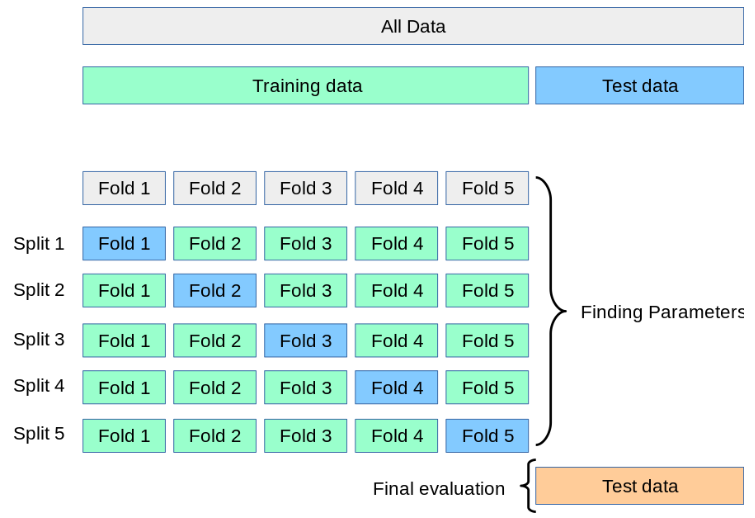

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Configuração de folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [ ]:
# Criação do modelo
modelo = GaussianNB()

In [ ]:
# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [ ]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)





# **MÁQUINAS DE VETORES DE SUPORTE (SVM)**

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [ ]:
from sklearn.svm import SVC

### **Validação Cruzada**

In [ ]:
from sklearn.model_selection import KFold, cross_validate

In [ ]:
# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [ ]:
# Criação do modelo
modelo = SVC(kernel='rbf', random_state=0, C = 2)
# kernel: tipo de separação: linear, rbf, polinomial e sigmoid.
# intensidade de regularização: quanto maior, menor a regularização, margem mais estreita.

In [ ]:
# Lembrando da separação de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores_esc , alvo, test_size = 0.3, random_state = 0)

In [ ]:
# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [ ]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

In [ ]:
# Treinar com os dados de treino completo
svm = SVC(kernel='rbf', random_state=0, C = 2)
svm.fit(x_treino, y_treino)

In [ ]:
previsoes_svm = svm.predict(x_teste)
previsoes_svm

In [ ]:
y_teste

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_svm) * 100.0))

In [ ]:
confusion_matrix(y_teste, previsoes_svm)

In [ ]:
print(classification_report(y_teste, previsoes_svm))

Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)

SVM = 87,51% (validação cruzada), 92,51% (treino) e 85,51% (teste) - 236 acertos (previsores_esc) - SVC(kernel='rbf', random_state=0, C = 2)



**Análise dados de treino**

In [ ]:
previsoes_treino = svm.predict(x_treino)

In [ ]:
accuracy_score(y_treino, previsoes_treino)

# **REGRESSÃO LOGÍSTICA**

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [ ]:
from sklearn.linear_model import LogisticRegression

### **Validação Cruzada**

In [ ]:
from sklearn.model_selection import KFold, cross_validate

# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [ ]:
# Lembrando da separação de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores3_esc , alvo, test_size = 0.3, random_state = 0)

In [ ]:
# Criação do modelo
modelo = LogisticRegression(random_state=0, max_iter=600, penalty="l2",
                               tol=0.0001, C=1, solver="lbfgs")
# C é a intensidade de regularização. Quanto maior, menor a regularização
# C > 0
# penalty é o tipo de regularização: l1, l2 e elasticnet
# solver: lbfgs, liblinear e saga.

# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [ ]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)

SVM = 87,51% (validação cruzada), 92,51% (treino) e 85,51% (teste) - 236 acertos (previsores_esc) - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 84,87% (validação cruzada), 86,11% (treino) e 86,23% - 238 acertos (teste): previsores3_esc - LogisticRegression(random_state=0, max_iter=600, penalty="l2", tol=0.0001, C=1,solver="lbfgs")

In [ ]:
# Treinamento com dados de treino completo
logistica = LogisticRegression(random_state=0, max_iter=600, penalty="l2",
                               tol=0.0001, C=1,solver="lbfgs")
logistica.fit(x_treino, y_treino)

In [ ]:
logistica.intercept_

In [ ]:
logistica.coef_

In [ ]:
previsoes_logistica = logistica.predict(x_teste)
previsoes_logistica

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_logistica) * 100.0))

In [ ]:
confusion_matrix(y_teste, previsoes_logistica)

**Análise dados de treino**

In [ ]:
previsoes_treino = logistica.predict(x_treino)
previsoes_treino

In [ ]:
accuracy_score(y_treino, previsoes_treino)

In [ ]:
probabilidades = logistica.predict_proba(x_treino)
probabilidades

# **APRENDIZAGEM BASEADA EM INSTÂNCIAS (KNN)**

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

### **Validação Cruzada**

In [ ]:
from sklearn.model_selection import KFold, cross_validate

# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [ ]:
# Lembrando da separação de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores_esc , alvo, test_size = 0.3, random_state = 0)

In [ ]:
x_treino.shape

In [ ]:
# Criação do modelo
modelo = KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [ ]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)

SVM = 87,51% (validação cruzada), 92,51% (treino) e 85,51% (teste) - 236 acertos (previsores_esc) - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 84,87% (validação cruzada), 86,11% (treino) e 86,23% - 238 acertos (teste): previsores3_esc - LogisticRegression(random_state=0, max_iter=600, penalty="l2", tol=0.0001, C=1,solver="lbfgs")

KNN = 87,21% (validação cruzada), 88,96% (treino) e 85,51% - 236 acertos (teste): previsores_esc - KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

In [ ]:
# Treinamento com dados de treino completo
knn = KNeighborsClassifier(n_neighbors=11, metric='minkowski', p=1)
knn.fit(x_treino, y_treino)

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html

In [ ]:
previsoes_knn = knn.predict(x_teste)
previsoes_knn

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_knn) * 100.0))

In [ ]:
confusion_matrix(y_teste, previsoes_knn)

**Análise dados de treino**

In [ ]:
previsoes_treino = knn.predict(x_treino)
previsoes_treino

In [ ]:
accuracy_score(y_treino, previsoes_treino)

# **ÁRVORE DE DECISÃO**

https://scikit-learn.org/stable/modules/tree.html

In [ ]:
from sklearn.tree import DecisionTreeClassifier

### **Validação Cruzada**

In [ ]:
from sklearn.model_selection import KFold, cross_validate

# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [ ]:
# Lembrando da separação de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores3 , alvo, test_size = 0.3, random_state = 0)

In [ ]:
# Criação do modelo
modelo = DecisionTreeClassifier(criterion='gini', random_state = 0,
                                max_depth=3, min_samples_split=2, min_samples_leaf=1)
# min_samples_split=2 (número mínimo de amostras em um nó)
# min_samples_leaf=1 (número mínimo de amostras em uma folha)
# max_leaf_nodes (número máximo de folhas)

# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

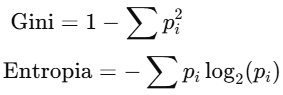

In [ ]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)

SVM = 87,51% (validação cruzada), 92,51% (treino) e 85,51% (teste) - 236 acertos (previsores_esc) - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 84,87% (validação cruzada), 86,11% (treino) e 86,23% - 238 acertos (teste): previsores3_esc - LogisticRegression(random_state=0, max_iter=600, penalty="l2", tol=0.0001, C=1,solver="lbfgs")

KNN = 87,21% (validação cruzada), 88,96% (treino) e 85,51% - 236 acertos (teste): previsores_esc - KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

Árvore de decisão = 83,30% (validação cruzada), 86,24% (treino) e 83,70% - 231 acertos (teste): previsores3 - DecisionTreeClassifier(criterion='gini', random_state = 0, max_depth=3)

**Análise dados de Teste**

In [ ]:
arvore = DecisionTreeClassifier(criterion='gini', random_state = 0, max_depth=3)
arvore.fit(x_treino, y_treino)

In [ ]:
previsoes_arvore = arvore.predict(x_teste)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_arvore) * 100.0))

In [ ]:
confusion_matrix(y_teste, previsoes_arvore)

**Análise dados de treino**

In [ ]:
previsoes_treino = arvore.predict(x_treino)

In [ ]:
accuracy_score(y_treino, previsoes_treino)

# **RANDOM FOREST**

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [ ]:
from sklearn.ensemble import RandomForestClassifier

### **Validação Cruzada**

In [ ]:
from sklearn.model_selection import KFold, cross_validate

# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [ ]:
# Lembrando da separação de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores3, alvo, test_size = 0.3, random_state = 0)

In [ ]:
# Criação do modelo
modelo = RandomForestClassifier(n_estimators=150, criterion='entropy',
                                random_state = 0, max_depth=5)
# n_estimators é o número de árvores (modelos).

# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [ ]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)

SVM = 87,51% (validação cruzada), 92,51% (treino) e 85,51% (teste) - 236 acertos (previsores_esc) - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 84,87% (validação cruzada), 86,11% (treino) e 86,23% - 238 acertos (teste): previsores3_esc - LogisticRegression(random_state=0, max_iter=600, penalty="l2", tol=0.0001, C=1,solver="lbfgs")

KNN = 87,21% (validação cruzada), 88,96% (treino) e 85,51% - 236 acertos (teste): previsores_esc - KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

Árvore de decisão = 83,30% (validação cruzada), 86,24% (treino) e 83,70% - 231 acertos (teste): previsores3 - DecisionTreeClassifier(criterion='gini', random_state = 0, max_depth=3)

Random Forest = 86,26% (validação cruzada), 91,36% (treino) e 85,51% - 236 acertos (teste): previsores3 - RandomForestClassifier(n_estimators=150, criterion='entropy', random_state = 0, max_depth=5)

**Análise Dados de Teste**

In [ ]:
random = RandomForestClassifier(n_estimators=150, criterion='entropy', random_state = 0, max_depth=5)
random.fit(x_treino, y_treino)

In [ ]:
previsoes_random = random.predict(x_teste)
previsoes_random

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_random) * 100.0))

In [ ]:
confusion_matrix(y_teste, previsoes_random)

**Análise dados de treino**

In [ ]:
previsoes_treino = random.predict(x_treino)

In [ ]:
accuracy_score(y_treino, previsoes_treino)

# **XGBOOST**

https://xgboost.readthedocs.io/en/stable/

In [ ]:
from xgboost import XGBClassifier

### **Validação Cruzada**

In [ ]:
from sklearn.model_selection import KFold, cross_validate

# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [ ]:
# Lembrando da separação de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores3 , alvo, test_size = 0.3, random_state = 0)

In [ ]:
# Criação do modelo
modelo = XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=250,
                       objective='binary:logistic', random_state=0)
# learning_rate: quanto cada nova árvore “pesa” no modelo final. Quanto maior, maior a chance de overfitting.
# Ex: Cada árvore contribui com 5% da correção completa.
# learning_rate = 0.1 → ~100 árvores
# learning_rate = 0.05 → ~200 árvores
# learning_rate = 0.01 → centenas ou milhares
# O objective: problema que o modelo está tentando resolver e
# qual função de perda (loss) será otimizada.
# binary:logistic=classificação binária com função sigmoid (probabilística)
# binary:hinge =	Classificação binária (classe direta, tipo SVM)
# multi:softprob =	Multiclasse (probabilidades)
# multi:softmax	= Multiclasse (classe direta)

# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [ ]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)

SVM = 87,51% (validação cruzada), 92,51% (treino) e 85,51% (teste) - 236 acertos (previsores_esc) - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 84,87% (validação cruzada), 86,11% (treino) e 86,23% - 238 acertos (teste): previsores3_esc - LogisticRegression(random_state=0, max_iter=600, penalty="l2", tol=0.0001, C=1,solver="lbfgs")

KNN = 87,21% (validação cruzada), 88,96% (treino) e 85,51% - 236 acertos (teste): previsores_esc - KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

Árvore de decisão = 83,30% (validação cruzada), 86,24% (treino) e 83,70% - 231 acertos (teste): previsores3 - DecisionTreeClassifier(criterion='gini', random_state = 0, max_depth=3)

Random Forest = 86,26% (validação cruzada), 91,36% (treino) e 85,51% - 236 acertos (teste): previsores3 - RandomForestClassifier(n_estimators=150, criterion='entropy', random_state = 0, max_depth=5)

XGBoost = 87,98% (validação cruzada), 91,55% (treino) e 86,59% - 239 acertos (teste): previsores3 - XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=250, objective='binary:logistic', random_state=0)

**Análise Dados de Teste**

In [ ]:
xg = XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=250, objective='binary:logistic', random_state=3)
xg.fit(x_treino,y_treino)

In [ ]:
previsoes_xg = xg.predict(x_teste)
previsoes_xg

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_xg) * 100.0))

In [ ]:
confusion_matrix(y_teste, previsoes_xg)

**Análise dados de treino**

In [ ]:
previsoes_treino = xg.predict(x_treino)

In [ ]:
accuracy_score(y_treino, previsoes_treino)

# **LIGHTGBM**

https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.train.html

In [ ]:
# Instalação do Algoritmo
!pip install lightgbm

In [ ]:
import lightgbm as lgb

In [ ]:
# Lembrando da separação de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores3 , alvo, test_size = 0.3, random_state = 0)

In [ ]:
# Dataset para treino
dataset = lgb.Dataset(x_treino,label=y_treino)
dataset

### **Validação Cruzada**

In [ ]:
from sklearn.model_selection import KFold, cross_validate
# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

**Hiperparâmetros**

**Controle de ajuste**

num_leaves : define o número de folhas a serem formadas em uma árvore. Não tem uma relação direta entre num_leaves e max_depth e, portanto, os dois não devem estar vinculados um ao outro.

max_depth : especifica a profundidade máxima ou nível até o qual a árvore pode crescer.

**Controle de velocidade**

learning_rate: taxa de aprendizagem, determina o impacto de cada árvore no resultado final.

max_bin : O valor menor de max_bin reduz muito tempo de procesamento, pois agrupa os valores do recurso em caixas discretas, o que é computacionalmente mais barato.

**Controle de precisão**

num_leaves : valor alto produz árvores mais profundas com maior precisão, mas leva ao overfitting.

max_bin : valores altos tem efeito semelhante ao causado pelo aumento do valor de num_leaves e também torna mais lento o procedimento de treinamento.

In [ ]:
# Criação do modelo
modelo = lgb.LGBMClassifier(num_leaves = 150, objective = 'binary',
                            max_depth = 4, learning_rate = 0.05, max_bin =100)

In [ ]:
# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [ ]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)

SVM = 87,51% (validação cruzada), 92,51% (treino) e 85,51% (teste) - 236 acertos (previsores_esc) - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 84,87% (validação cruzada), 86,11% (treino) e 86,23% - 238 acertos (teste): previsores3_esc - LogisticRegression(random_state=0, max_iter=600, penalty="l2", tol=0.0001, C=1,solver="lbfgs")

KNN = 87,21% (validação cruzada), 88,96% (treino) e 85,51% - 236 acertos (teste): previsores_esc - KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

Árvore de decisão = 83,30% (validação cruzada), 86,24% (treino) e 83,70% - 231 acertos (teste): previsores3 - DecisionTreeClassifier(criterion='gini', random_state = 0, max_depth=3)

Random Forest = 86,26% (validação cruzada), 91,36% (treino) e 85,51% - 236 acertos (teste): previsores3 - RandomForestClassifier(n_estimators=150, criterion='entropy', random_state = 0, max_depth=5)

XGBoost = 87,98% (validação cruzada), 91,55% (treino) e 86,59% - 239 acertos (teste): previsores3 - XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=250, objective='binary:logistic', random_state=0)

LightGBM = 87,66% (validação cruzada), 93,62% (treino) e 85,87% - 237 acertos (teste): previsores - lgb.LGBMClassifier(num_leaves = 150, objective = 'binary',  max_depth = 4, learning_rate = 0.05, max_bin =100)

**Análise Dados de Teste**

In [ ]:
# Parâmetros
parametros = {'num_leaves':150, # número de folhas
              'objective':'binary', # classificação Binária
              'max_depth':4,
              'learning_rate':0.05,
              'max_bin':100}

In [ ]:
lgbm=lgb.train(parametros,dataset,num_boost_round=200)

In [ ]:
# Marcação do tempo de execução
from datetime import datetime
inicio=datetime.now()
lgbm=lgb.train(parametros,dataset)
fim=datetime.now()

tempo = fim - inicio
tempo

In [ ]:
previsoes_lgbm = lgbm.predict(x_teste)
previsoes_lgbm

In [ ]:
previsoes_lgbm.shape

In [ ]:
# Quando for menor que 5 considera 0 e quando for maior ou igual a 5 considera 1
for i in range(0, 276):
    if previsoes_lgbm[i] >= .5:
       previsoes_lgbm[i] = 1
    else:
       previsoes_lgbm[i] = 0

In [ ]:
previsoes_lgbm

In [ ]:
y_teste

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_lgbm) * 100.0))

In [ ]:
confusion_matrix(y_teste, previsoes_lgbm)

**Análise dados de treino**

In [ ]:
previsoes_treino = lgbm.predict(x_treino)

In [ ]:
# Quando for menor que 5 considera 0 e quando for maior ou igual a 5 considera 1
for i in range(0, 641):
    if previsoes_treino[i] >= .5:
       previsoes_treino[i] = 1
    else:
       previsoes_treino[i] = 0

In [ ]:
previsoes_treino

In [ ]:
accuracy_score(y_treino, previsoes_treino)

# **CATBOOST**

https://catboost.ai/en/docs/

In [ ]:
#Instalação
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
df

In [ ]:
previsores4 = df.iloc[:, 0:11]

In [ ]:
previsores4.head()

In [ ]:
alvo4 = df.iloc[:, 11]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores4, alvo4, test_size = 0.3, random_state = 0)

### **Validação Cruzada**

In [ ]:
# lista das colunas que são texto
colunas_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [ ]:
from catboost import cv, Pool

pool = Pool(x_treino, y_treino, cat_features=colunas_cat)

params = {
    "iterations": 120,
    "eval_metric": "Accuracy",
    "loss_function": "Logloss",
    "random_seed": 0,
    "verbose": False
}

#Obs.: loss_function:
# Classificação binária	"Logloss"
# Multiclasse	"MultiClass"
# Regressão	"RMSE"

resultado = cv(pool, params, fold_count=10)

In [ ]:
resultado.tail(20)

In [ ]:
resultado["test-Accuracy-mean"].max()

In [ ]:
resultado["train-Accuracy-mean"].max()

**Acurácia: 86,13% (validação)**

**Acurácia: 92,74% (média treino)**


Naive Bayes = 85,64% (validação cruzada), 85,89% (treino) e 84,78% (teste) - 234 acertos (previsores3_esc)

SVM = 87,51% (validação cruzada), 92,51% (treino) e 85,51% (teste) - 236 acertos (previsores_esc) - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 84,87% (validação cruzada), 86,11% (treino) e 86,23% - 238 acertos (teste): previsores3_esc - LogisticRegression(random_state=0, max_iter=600, penalty="l2", tol=0.0001, C=1,solver="lbfgs")

KNN = 87,21% (validação cruzada), 88,96% (treino) e 85,51% - 236 acertos (teste): previsores_esc - KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

Árvore de decisão = 83,30% (validação cruzada), 86,24% (treino) e 83,70% - 231 acertos (teste): previsores3 - DecisionTreeClassifier(criterion='gini', random_state = 0, max_depth=3)

Random Forest = 86,26% (validação cruzada), 91,36% (treino) e 85,51% - 236 acertos (teste): previsores3 - RandomForestClassifier(n_estimators=150, criterion='entropy', random_state = 0, max_depth=5)

XGBoost = 87,98% (validação cruzada), 91,55% (treino) e 86,59% - 239 acertos (teste): previsores3 - XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=250, objective='binary:logistic', random_state=0)

LightGBM = 87,66% (validação cruzada), 93,62% (treino) e 85,87% - 237 acertos (teste): previsores - lgb.LGBMClassifier(num_leaves = 150, objective = 'binary',  max_depth = 4, learning_rate = 0.05, max_bin =100)

CatBoost = 86,13% (validação cruzada), 92,74% (treino) e 85,87% - 237 acertos (teste) - CatBoostClassifier(iterations=108, eval_metric="Accuracy", loss_function="Logloss", random_seed=0)

In [ ]:
best_iter = resultado["test-Accuracy-mean"].idxmax()
best_iter

**Análise dados de treino**

In [ ]:
from catboost import CatBoostClassifier

modelo_final = CatBoostClassifier(
    iterations=best_iter,
    eval_metric="Accuracy",
    loss_function="Logloss",
    random_seed=0,
    verbose=0
)

modelo_final.fit(x_treino, y_treino, cat_features=colunas_cat)

In [ ]:
acuracia_treino = modelo_final.score(x_treino, y_treino)

print(acuracia_treino)

**Análise Dados Teste**

In [ ]:
acuracia_teste = modelo_final.score(x_teste, y_teste)

print(acuracia_teste)

In [ ]:
y_pred = modelo_final.predict(x_teste)
y_pred

In [ ]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_teste, y_pred)
print(matriz)

# **Salvando dados para Deploy**

In [ ]:
previsores

In [ ]:
alvo

In [ ]:
np.savetxt('previsores.csv', previsores, delimiter=',')

In [ ]:
np.savetxt('alvo.csv', alvo, delimiter=',')

# **NOÇÕES DE OTIMIZAÇÃO DE HIPERPARÂMETROS**

## **Grid Search (classificador Gradient Boosting)**

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Criando o algoritmo
gbm = GradientBoostingClassifier(random_state=0)

In [ ]:
# Determinando o espaço do hiperparâmetro
param_grid = dict(
    n_estimators=[20, 50, 100, 250],
    learning_rate=[0.05, 0.1, 0.5],
    max_depth=[1,2,3,4,5],
    )

In [ ]:
print('Número de combinações de Hiperparâmetros: ',
      len(param_grid['n_estimators']) * len(param_grid['learning_rate']) * len(param_grid['max_depth']))

In [ ]:
# Configurando a procura com o Grid search
grid_search = GridSearchCV(gbm, param_grid, scoring='roc_auc', cv=4)

In [ ]:
# Configurando os melhores hiperparâmetros
grid_search.fit(x_treino, y_treino)

In [ ]:
# Melhores Hiperparâmetros
grid_search.best_params_

In [ ]:
# Relação dos dados para todos os modelos

resultado = pd.DataFrame(grid_search.cv_results_)
print(resultado.shape)
resultado.head(3)

In [ ]:
# Ordenando os melhores resultados
resultado.sort_values(by='mean_test_score', ascending=False, inplace=True)

resultado.reset_index(drop=True, inplace=True)

resultado[['param_max_depth', 'param_learning_rate', 'param_n_estimators',
    'mean_test_score', 'std_test_score']].head()

# **DESAFIO 1**

DESENVOLVER E SELECIONAR O MELHOR ALGORITMO DE MACHINE LEARNING DE CLASSIFICAÇÃO PARA O DATASET DO LINK A SEGUIR:

https://www.kaggle.com/uciml/breast-cancer-wisconsin-data